1.Persiapan Lingkungan dan Library
Tahap pertama adalah menginstal library Sastrawi untuk stemming bahasa Indonesia, serta mengimpor library dasar seperti Pandas untuk manipulasi data, NLTK untuk pemrosesan teks, dan Matplotlib/Seaborn untuk visualisasi.

In [1]:

!pip install Sastrawi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Unduh resource NLTK yang dibutuhkan
nltk.download('punkt_tab')
nltk.download('stopwords')

print("Tahap 1 Selesai: Library siap digunakan!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Tahap 1 Selesai: Library siap digunakan!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


2. Memuat Dataset dan Eksplorasi
Data yang digunakan adalah dataset publik mengenai Tweet PPKM. Data dimuat dari file TSV, kemudian dilakukan pengecekan jumlah baris dan visualisasi awal berupa *Countplot* untuk melihat distribusi sentimen pada teks.

👇 SILAKAN KLIK TOMBOL 'Choose Files' DI BAWAH INI 👇
Lalu pilih file dataset 'INA_TweetsPPKM_Labeled_Pure.csv'


Saving INA_TweetsPPKM_Labeled_Pure.csv to INA_TweetsPPKM_Labeled_Pure.csv

File berhasil masuk! Sedang membaca data...

Total data keseluruhan: 23644 baris


,Date,User,Tweet,sentiment
0,2022-03-31 14:32:04+00:00,pikobar_jabar,Ketahui informasi pembagian #PPKM di wilayah J...,1
1,2022-03-31 09:26:00+00:00,inewsdotid,Tempat Ibadah di Wilayah PPKM Level 1 Boleh Be...,1
2,2022-03-31 05:02:34+00:00,vdvc_talk,"Juru bicara Satgas Covid-19, Wiku Adisasmito m...",1
3,2022-03-30 14:23:10+00:00,pikobar_jabar,Ketahui informasi pembagian #PPKM di wilayah J...,1
4,2022-03-30 11:28:57+00:00,tvOneNews,Kementerian Agama menerbitkan Surat Edaran Nom...,1


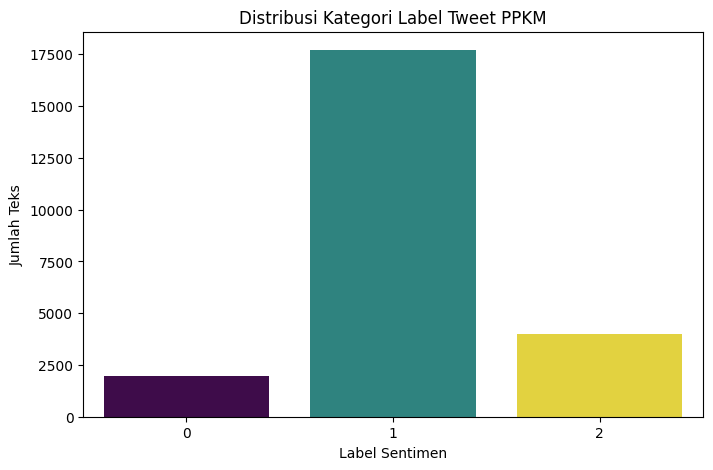

In [2]:

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

print("👇 SILAKAN KLIK TOMBOL 'Choose Files' DI BAWAH INI 👇")
print("Lalu pilih file dataset 'INA_TweetsPPKM_Labeled_Pure.csv'")


uploaded = files.upload()


nama_file = list(uploaded.keys())[0]

print("\nFile berhasil masuk! Sedang membaca data...")

# Membaca dataset
df = pd.read_csv(io.BytesIO(uploaded[nama_file]), sep='\t')

print(f"\nTotal data keseluruhan: {df.shape[0]} baris")


display(df.head())

# --- VISUALISASI 1: Distribusi Label ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', hue='sentiment', palette='viridis', legend=False)
plt.title('Distribusi Kategori Label Tweet PPKM')
plt.xlabel('Label Sentimen')
plt.ylabel('Jumlah Teks')
plt.show()

3.Text Preprocessing

Tahap ini adalah inti dari pembersihan data teks yang terdiri dari 4 proses utama yang diwajibkan:

1. Cleaning: Mengubah teks menjadi huruf kecil (case folding), serta menghapus URL, sebutan akun (@), tagar (#), angka, dan tanda baca.

2. Tokenization: Memecah kalimat utuh    menjadi daftar kata (token).

3. Stopword Removal: Membuang kata-kata umum yang tidak memiliki makna signifikan (seperti "yang", "di", "dan") menggunakan kamus NLTK yang ditambah dengan beberapa kata slang Twitter.

4. Stemming:Mengembalikan kata berimbuhan menjadi kata dasar menggunakan library Sastrawi.

In [3]:

!pip install Sastrawi
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Pastikan NLTK resource sudah terunduh
nltk.download('punkt_tab')
nltk.download('stopwords')

# 1. Ambil sampel OTOMATIS: Jika data > 1500 ambil 1500, jika kurang ambil semuanya
jumlah_sampel = min(1500, len(df))
df_sample = df.sample(n=jumlah_sampel, random_state=42).reset_index(drop=True)

# alat pembersih (Sastrawi & NLTK)
factory = StemmerFactory()
stemmer = factory.create_stemmer()

list_stopwords = set(stopwords.words('indonesian'))
list_stopwords.update(['yg', 'dg', 'rt', 'dgn', 'ny', 'd', 'klo', 'kalo', 'amp', 'biar', 'bikin', 'bilang', 'gak', 'ga', 'krn', 'nya', 'nih', 'sih', 'si', 'tau', 'tdk', 'tuh', 'utk', 'ya', 'jd', 'jgn', 'sdh', 'aja', 'n', 't', 'nyg', 'hehe', 'pen', 'u', 'nan', 'loh', 'di', 'ke', 'dari', 'gw', 'gue', 'ppkm'])

# Fungsi utama pembersihan
def text_preprocessing(text):
    if pd.isna(text): return ""

    text = str(text).lower() # Huruf kecil
    text = re.sub(r"http\S+", "", text) # Hapus Link
    text = re.sub(r"@\w+", "", text) # Hapus Mention
    text = re.sub(r"#\w+", "", text) # Hapus Hashtag
    text = re.sub(r"\d+", "", text) # Hapus Angka
    text = re.sub(r"[^\w\s]", "", text) # Hapus Tanda Baca

    tokens = word_tokenize(text) # Pecah kata
    tokens = [word for word in tokens if word not in list_stopwords] # Buang stopword
    return " ".join([stemmer.stem(word) for word in tokens]) # Kembalikan ke kata dasar

print(f"Sedang membersihkan {jumlah_sampel} teks... (Mohon tunggu sebentar)")

# Terapkan pembersihan ke kolom 'Tweet' dan buat kolom baru 'teks_bersih'
df_sample['teks_bersih'] = df_sample['Tweet'].apply(text_preprocessing)
print("Pembersihan selesai!")

# Tampilkan hasilnya untuk memastikan teks sudah bersih
display(df_sample[['Tweet', 'teks_bersih']].head(10))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sedang membersihkan 1500 teks... (Mohon tunggu sebentar)
Pembersihan selesai!


,Tweet,teks_bersih
0,"Datangi Pemilik Warung, Bripka Iwan Handayana ...",datang milik warung bripka iwan handayana himb...
1,"PPKM Tahap Dua, PKL Diberikan kelonggaran berj...",tahap pkl longgar jual wib
2,#PPKM nambah lv nambah harga ga sih,nambah lv nambah harga
3,"Terjadi Tren perbaikan pada kasus COVID-19, un...",tren baik covid presiden lanjut tgl september ...
4,Setiap orang itu baik hanya saja dia belum ten...,orang sesuai porsi
5,Visi dan Misi dari P@ntastis.\n#fco #funcoin #...,visi misi p ikut like share akun medsos update...
6,"Meski #PPKM, KBM Daring Tetap Jalan https://t....",kbm daring jalan via
7,"Hai Sahabat JD, #MinjoyInfo kembali hadir nih...",hai sahabat hadir kasih opsi bayar online saha...
8,"Mundur lebih bermartabat, dari pada Diturunkan...",mundur martabat turun
9,Pria paruh baya yang kesehariannya menjual aga...,pria paruh baya hari jual agaragar keliling mi...


4. Representasi Teks dan Perbandingan Performa
Pada tahap ini, dataset dibagi menjadi data latih (80%) dan data uji (20%). Kita mengimplementasikan dua metode representasi teks sesuai ketentuan ujian, yaitu:
1.Bag-of-Words (BoW) menggunakan `CountVectorizer`.
2. TF-IDF menggunakan `TfidfVectorizer`.

Model klasifikasi teks yang digunakan adalah Naive Bayes (`MultinomialNB`). Setelah model dilatih, kita akan membandingkan akurasi dari kedua metode representasi tersebut.

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 1. Pastikan tidak ada data teks yang kosong (NaN) setelah dibersihkan
df_sample['teks_bersih'] = df_sample['teks_bersih'].fillna('')

# 2. Pisahkan fitur teks (X) dan label sentimen (y)
X = df_sample['teks_bersih']
y = df_sample['sentiment']

# 3. Bagi data: 80% untuk latihan (train) dan 20% untuk ujian (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- EVALUASI PERFORMANSI MODEL ---\n")

# --- METODE 1: BAG-OF-WORDS (BoW) ---
vectorizer_bow = CountVectorizer()
X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)

model_bow = MultinomialNB()
model_bow.fit(X_train_bow, y_train)
y_pred_bow = model_bow.predict(X_test_bow)
acc_bow = accuracy_score(y_test, y_pred_bow)
print(f"1. Akurasi metode Bag-of-Words (BoW) : {acc_bow * 100:.2f}%")

# METODE 2: TF-IDF
vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f"2. Akurasi metode TF-IDF             : {acc_tfidf * 100:.2f}%\n")

# KESIMPULAN PERBANDINGAN
print("--- KESIMPULAN ---")
if acc_tfidf > acc_bow:
    print("Metode TF-IDF memberikan performa/akurasi yang LEBIH BAIK dibandingkan Bag-of-Words.")
elif acc_bow > acc_tfidf:
    print("Metode Bag-of-Words memberikan performa/akurasi yang LEBIH BAIK dibandingkan TF-IDF.")
else:
    print("Kedua metode representasi teks memberikan performa yang SAMA BAIKNYA.")

--- EVALUASI PERFORMANSI MODEL ---

1. Akurasi metode Bag-of-Words (BoW) : 79.67%
2. Akurasi metode TF-IDF             : 75.00%

--- KESIMPULAN ---
Metode Bag-of-Words memberikan performa/akurasi yang LEBIH BAIK dibandingkan TF-IDF.


5. Visualisasi Word Cloud
Sebagai visualisasi kedua, kita membuat Word Cloud dari sekumpulan teks yang telah melalui tahap preprocessing. Visualisasi ini berguna untuk melihat kata apa saja yang paling dominan muncul dalam dataset perbincangan mengenai PPKM.

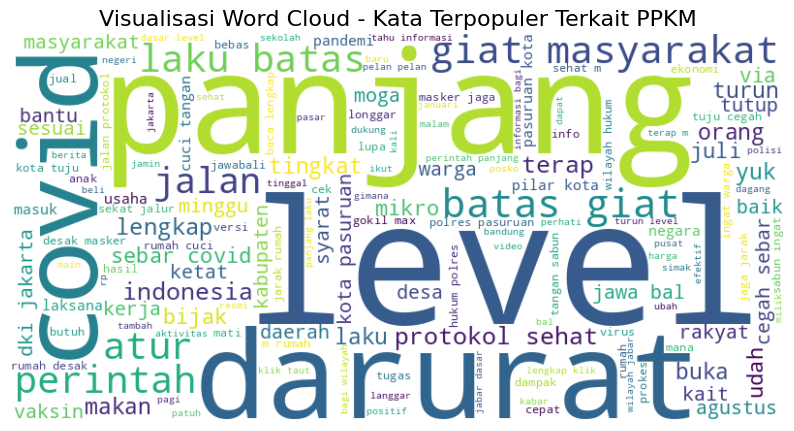

In [5]:
from wordcloud import WordCloud


semua_teks = " ".join(df_sample['teks_bersih'])

# Membuat objek WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=150).generate(semua_teks)

# Menampilkan WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Visualisasi Word Cloud - Kata Terpopuler Terkait PPKM', fontsize=16)
plt.show()